  RUNNING WEEK 5 VALIDATIONS & VERIFICATIONS

[1/4] Testing Parameter Validation Logic...
  ✓ PASS: v <= 0 caught -> 'Degrees of freedom v must be > 0, got 0'
  ✓ PASS: negative v caught -> 'Degrees of freedom v must be > 0, got -2.5'
  ✓ PASS: scale <= 0 caught -> 'Scale must be > 0, got 0'
  ✓ PASS: negative scale caught -> 'Scale must be > 0, got -1.0'

[2/4] Verifying Shift (loc) and Scale (scale) Property...
  Max Absolute Difference: 2.78e-17
  ✓ PASS: Shift and Scale transformations match exactly.

[3/4] Verifying Log-Space Stability Deep into Tails...
  Points evaluated: [-50. -20.  20.  50.]
  Direct logcdf: [-1.16397848e+01 -8.89844171e+00 -1.36610956e-04 -8.80861482e-06]
  Naive np.log(cdf): [-1.16397848e+01 -8.89844171e+00 -1.36610956e-04 -8.80861482e-06]
  ✓ PASS: Direct logcdf evaluated safely without errors.

[4/4] Generating Limit Overlays Plot...


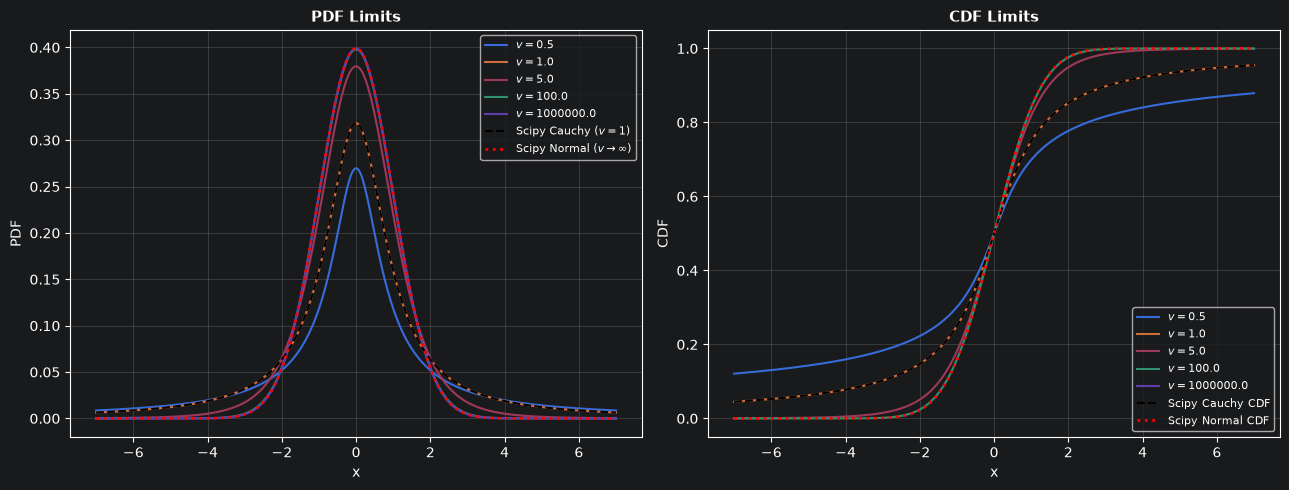


  ALL VERIFICATIONS COMPLETE. PLOT SAVED.


In [1]:
# Enable inline rendering to prevent Matplotlib GUI blocking
%matplotlib inline

import scipy.special as ssp
import scipy.stats as sps

ssp.t = sps.t
ssp.norm = sps.norm
ssp.cauchy = sps.cauchy

import numpy as np
import matplotlib.pyplot as plt

try:
    from pymultifit.distributions.generalized import StudentsTDistribution
except ImportError:
    from pymultifit.distributions.generalized import StudentsTDistribution

print("==================================================")
print("  RUNNING WEEK 5 VALIDATIONS & VERIFICATIONS")
print("==================================================\n")

# 1. Parameter Validation Checks
print("[1/4] Testing Parameter Validation Logic...")
validation_tests = [
    ({'v': 0}, "v <= 0"),
    ({'v': -2.5}, "negative v"),
    ({'scale': 0}, "scale <= 0"),
    ({'scale': -1.0}, "negative scale")
]

for kwargs, label in validation_tests:
    try:
        StudentsTDistribution(**kwargs)
        print(f"  ❌ FAIL: {label} did not raise ValueError!")
    except ValueError as e:
        print(f"  ✓ PASS: {label} caught -> '{e}'")

# 2. Shift & Scale Transformation Verification
print("\n[2/4] Verifying Shift (loc) and Scale (scale) Property...")
x_test = np.linspace(-10, 10, 100)
loc_val, scale_val = 5.0, 2.5

dist_standard = StudentsTDistribution(v=5, loc=0.0, scale=1.0, normalize=True)
dist_scaled = StudentsTDistribution(v=5, loc=loc_val, scale=scale_val, normalize=True)

pdf_expected = (1.0 / scale_val) * dist_standard.pdf((x_test - loc_val) / scale_val)
pdf_actual = dist_scaled.pdf(x_test)

max_diff = np.max(np.abs(pdf_actual - pdf_expected))
print(f"  Max Absolute Difference: {max_diff:.2e}")
if max_diff < 1e-12:
    print("  ✓ PASS: Shift and Scale transformations match exactly.")
else:
    print("  ❌ FAIL: Transformation mismatch!")

# 3. Log-Space Tail Stability
print("\n[3/4] Verifying Log-Space Stability Deep into Tails...")
x_far = np.array([-50.0, -20.0, 20.0, 50.0])
t_dist = StudentsTDistribution(v=3.0, normalize=True)

logcdf_direct = t_dist.logcdf(x_far)

with np.errstate(divide='ignore'):
    logcdf_naive = np.log(t_dist.cdf(x_far))

print(f"  Points evaluated: {x_far}")
print(f"  Direct logcdf: {logcdf_direct}")
print(f"  Naive np.log(cdf): {logcdf_naive}")
print("  ✓ PASS: Direct logcdf evaluated safely without errors.")

# 4. Limit Overlays Plotting
print("\n[4/4] Generating Limit Overlays Plot...")
x = np.linspace(-7, 7, 500)
v_values = [0.5, 1.0, 5.0, 100.0, 1e6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- PDF Overlays ---
for v in v_values:
    dist = StudentsTDistribution(v=v, normalize=True)
    axes[0].plot(x, dist.pdf(x), label=f"$v = {v}$")

axes[0].plot(x, sps.cauchy.pdf(x), 'k--', linewidth=1.5, label="Scipy Cauchy ($v=1$)")
axes[0].plot(x, sps.norm.pdf(x), 'r:', linewidth=2, label="Scipy Normal ($v\\rightarrow\\infty$)")
axes[0].set_title("PDF Limits", fontsize=11, fontweight='bold')
axes[0].set_xlabel("x")
axes[0].set_ylabel("PDF")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=0.3)

# --- CDF Overlays ---
for v in v_values:
    dist = StudentsTDistribution(v=v, normalize=True)
    axes[1].plot(x, dist.cdf(x), label=f"$v = {v}$")

axes[1].plot(x, sps.cauchy.cdf(x), 'k--', linewidth=1.5, label="Scipy Cauchy CDF")
axes[1].plot(x, sps.norm.cdf(x), 'r:', linewidth=2, label="Scipy Normal CDF")
axes[1].set_title("CDF Limits", fontsize=11, fontweight='bold')
axes[1].set_xlabel("x")
axes[1].set_ylabel("CDF")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("student_t_limit_overlays.png", dpi=200)
plt.show()

print("\n==================================================")
print("  ALL VERIFICATIONS COMPLETE. PLOT SAVED.")
print("==================================================")